In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

In [3]:
s_is = 25 * 1.65 ** np.arange(10)
real_p_i = np.array([6.0, 0.0, 5.15, 0.65, 4.2, 2.55, 1.55, 0.95, 0.55, 0.35]) # x = 123.8
p_is = np.round(real_p_i * 20) / 20

In [4]:
def computeCosine(s: float, p: float, x: float) -> float:
    return np.cos(2 * np.pi / s * x - p)


def objectiveFunction(x: float) -> float:
    cosines_at_x = np.array(
        [computeCosine(s, p, x) for s, p in zip(s_is, p_is)]
    )
    error_at_x = np.abs(cosines_at_x - 1)
    return np.sum(error_at_x)

def objectiveFunctionArray(start=0, stop=22_000, step=2) -> np.ndarray:
    x = np.arange(start, stop, step)
    cosines = np.array(
        [np.cos(2 * np.pi / s * x - p) for s, p in zip(s_is, p_is)]
    )
    error = np.abs(cosines - 1)
    return np.sum(error, axis=0)

def findMinsIdxs(error: np.ndarray, thresh=2) -> np.ndarray:
    lows = np.concat(([False], error < thresh, [False])) # pad with Falses
    transitions = np.diff(lows.astype(np.int8))
    starts, stops = np.where(transitions == 1)[0], np.where(transitions == -1)[0]
    return np.column_stack((starts, stops))

def runOptimize(mins_idxs: np.ndarray, step_size=2) -> float:
    mins_x_ranges = mins_idxs * step_size
    for (start, stop) in mins_x_ranges:
        opt = minimize(objectiveFunction, (start + stop) / 2, bounds=[(start, stop)])
        if opt.fun < 0.1:
            return float(opt.x[0])
    return -1

def phasesToLocation1DOptimize() -> float:
    coarse_sweep = objectiveFunctionArray()
    mins = findMinsIdxs(coarse_sweep)
    return runOptimize(mins)

phasesToLocation1DOptimize()

123.84633030116167

In [5]:
import math
TAU = np.pi * 2
for _ in range(500):
    x = np.random.random() * 2_000 # [0, 500)
    s_is = 25 * 1.65 ** np.arange(10)


    n = np.floor(x / s_is)
    p_is = TAU * x / s_is - TAU * n
    rounded_p_i = np.round(p_is * 20) / 20

    data = np.zeros((10,2))
    data[:, 0] = s_is # 1st col
    data[:, 1] = rounded_p_i # 2nd col

    x_guess = phasesToLocation1DOptimize()
    if math.isclose(x, x_guess, rel_tol=25/20):
        print('😀', end=' ')
    else:
        print(f'\nFAILED: {x=}, {x_guess=}, {data=}')
        break
print()

😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 😀 

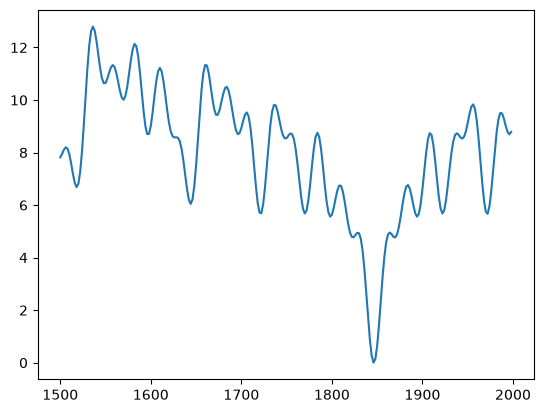

In [13]:
x = np.arange(1500, 2000, 2)
cosines = np.array(
    [np.cos(2 * np.pi / s * x - p) for s, p in zip(s_is, p_is)]
)
error = np.abs(cosines - 1)
sumerr =  np.sum(error, axis=0)

plt.plot(x, sumerr)